# MLB Pitch Velocity Prediction Project

## About the Dataset

This dataset contains MLB pitch-level tracking data collected 2015-2018 from Kaggle. The data includes pitch movement, spin rate, pitch type, and game situation variables used to predict pitch velocity.

Dataset Link:
https://www.kaggle.com/datasets/pschale/mlb-pitch-data-20152018

In [2]:
#Load all the libraies we want/need. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("done")

done


In [3]:
# load dataset. 

df = pd.read_csv("pitches.csv", low_memory=False)

print("Data Loaded")

Data Loaded


In [4]:
# We will check out the columns

df.columns.tolist()


['px',
 'pz',
 'start_speed',
 'end_speed',
 'spin_rate',
 'spin_dir',
 'break_angle',
 'break_length',
 'break_y',
 'ax',
 'ay',
 'az',
 'sz_bot',
 'sz_top',
 'type_confidence',
 'vx0',
 'vy0',
 'vz0',
 'x',
 'x0',
 'y',
 'y0',
 'z0',
 'pfx_x',
 'pfx_z',
 'nasty',
 'zone',
 'code',
 'type',
 'pitch_type',
 'event_num',
 'b_score',
 'ab_id',
 'b_count',
 's_count',
 'outs',
 'pitch_num',
 'on_1b',
 'on_2b',
 'on_3b']

In [5]:
#Now we need to set the target and features

target = "start_speed"

features = [
    "pitch_type",
    "b_count",
    "s_count",
    "outs",
    "pitch_num",
    "on_1b",
    "on_2b",
    "on_3b",
    "spin_rate",
    "break_angle",
    "break_length",
    "pfx_x",
    "pfx_z"
]

print("target and features set")

target and features set


In [6]:
df.head()

,px,pz,start_speed,end_speed,spin_rate,spin_dir,break_angle,break_length,break_y,ax,...,event_num,b_score,ab_id,b_count,s_count,outs,pitch_num,on_1b,on_2b,on_3b
0,0.416,2.963,92.9,84.1,2305.052,159.235,-25.0,3.2,23.7,7.665,...,3.0,0.0,2.015000e+09,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.191,2.347,92.8,84.1,2689.935,151.402,-40.7,3.4,23.7,12.043,...,4.0,0.0,2.015000e+09,0.0,1.0,0.0,2.0,0.0,0.0,0.0
2,-0.518,3.284,94.1,85.2,2647.972,145.125,-43.7,3.7,23.7,14.368,...,5.0,0.0,2.015000e+09,0.0,2.0,0.0,3.0,0.0,0.0,0.0
3,-0.641,1.221,91.0,84.0,1289.590,169.751,-1.3,5.0,23.8,2.104,...,6.0,0.0,2.015000e+09,0.0,2.0,0.0,4.0,0.0,0.0,0.0
4,-1.821,2.083,75.4,69.6,1374.569,280.671,18.4,12.0,23.8,-10.280,...,7.0,0.0,2.015000e+09,1.0,2.0,0.0,5.0,0.0,0.0,0.0


# Clean the Data

In [7]:
# Create a data frame with only what we need

model_df = df[features + [target]].copy()

print("done")

done


In [8]:
# Check missing values in modeling dataframe
print(model_df.isnull().sum())

pitch_type      12254
b_count             1
s_count             1
outs                1
pitch_num           1
on_1b               1
on_2b               1
on_3b               1
spin_rate       12253
break_angle     12253
break_length    12253
pfx_x           12207
pfx_z           12207
start_speed     12178
dtype: int64


In [9]:
# Looks like we are missing some we will drop the missing values. 

model_df = model_df.dropna(subset=["start_speed"])
print("missing dropped")


missing dropped


In [10]:
print(model_df["start_speed"].isnull().sum())

0


In [11]:
# Check for duplicates

print(model_df.duplicated().sum())

0


### Sweet no duplicates. Almost done cleaning

In [12]:
#Lets work on the feautures

model_df = model_df.dropna(subset=["pitch_type"])

print("missing pitches dropped")

model_df = model_df.dropna(subset = ["b_count", "s_count", "outs", "pitch_num", "on_1b","on_2b","on_3b"])

print("other missing dropped")

missing pitches dropped
other missing dropped


In [13]:
print(model_df.isnull().sum())

pitch_type      0
b_count         0
s_count         0
outs            0
pitch_num       0
on_1b           0
on_2b           0
on_3b           0
spin_rate       0
break_angle     0
break_length    0
pfx_x           0
pfx_z           0
start_speed     0
dtype: int64


### I noticed some metrics were missing we will just replace these with the median so it dosent throw off the numbers. 

In [14]:
metric_cols = [
    "spin_rate",
    "break_angle",
    "break_length",
    "pfx_x",
    "pfx_z"
]

for col in metric_cols:
    model_df[col] = model_df[col].fillna(
        model_df[col].median()
    )

print("metrics fixed")


metrics fixed


In [15]:
# check and see if they are fixed
print(model_df.isnull().sum())

pitch_type      0
b_count         0
s_count         0
outs            0
pitch_num       0
on_1b           0
on_2b           0
on_3b           0
spin_rate       0
break_angle     0
break_length    0
pfx_x           0
pfx_z           0
start_speed     0
dtype: int64


In [16]:
# Remove unrealistic pitch velocities

model_df = model_df[
    (model_df["start_speed"] >= 50) &
    (model_df["start_speed"] <= 105)
]

print(model_df["start_speed"].describe())

count    2.511364e+06
mean     8.834050e+01
std      6.014316e+00
min      5.000000e+01
25%      8.430000e+01
50%      8.970000e+01
75%      9.290000e+01
max      1.050000e+02
Name: start_speed, dtype: float64


### Interpretation

Pitch velocities below 50 MPH were removed from the dataset because they likely represented recording errors, position-player pitches, or non-competitive throws. Filtering these outliers improved model stability and prediction performance.

# EDA

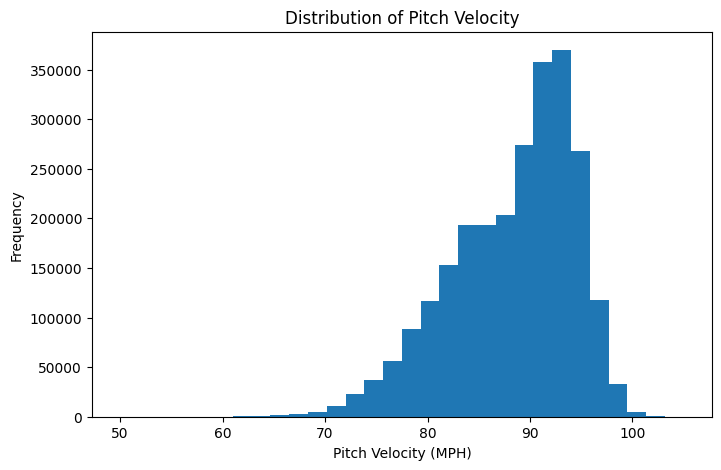

In [17]:
plt.figure(figsize=(8,5))

plt.hist(model_df["start_speed"], bins=30)

plt.xlabel("Pitch Velocity (MPH)")
plt.ylabel("Frequency")
plt.title("Distribution of Pitch Velocity")

plt.show()

### Interpretation

#### The histogram shows that most MLB pitch velocities fall between roughly 80–95 MPH, with the highest concentration occurring around 90–93 MPH. The distribution appears slightly left-skewed, with fewer low-velocity pitches present in the dataset.

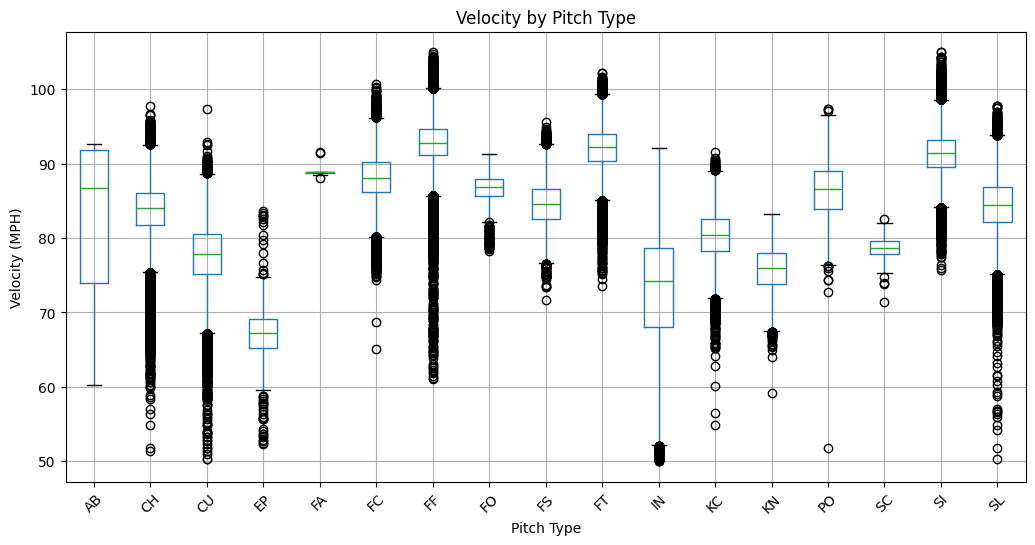

In [18]:
model_df.boxplot(
    column="start_speed",
    by="pitch_type",
    figsize=(12,6)
)

plt.xticks(rotation=45)

plt.xlabel("Pitch Type")
plt.ylabel("Velocity (MPH)")
plt.title("Velocity by Pitch Type")

plt.suptitle("")

plt.show()

### Interpretation

#### The boxplot demonstrates that pitch velocity varies significantly across pitch types. Fastballs generally exhibit the highest median velocities, while off-speed pitches such as changeups and curveballs tend to have lower median velocities. Several outliers are present across multiple pitch types, indicating occasional unusually fast or slow pitches.

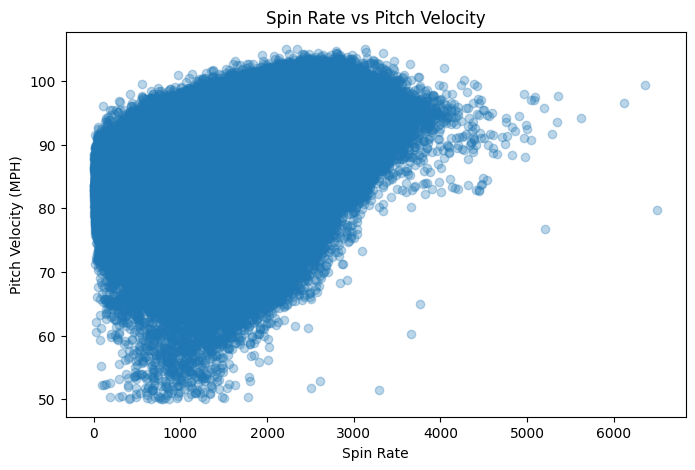

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    model_df["spin_rate"],
    model_df["start_speed"],
    alpha=0.3
)

plt.xlabel("Spin Rate")
plt.ylabel("Pitch Velocity (MPH)")
plt.title("Spin Rate vs Pitch Velocity")

plt.show()

### Interpretation

#### The scatterplot shows a positive relationship between spin rate and pitch velocity. As spin rate increases, pitch velocity generally increases as well. However, the points are widely spread out, which means spin rate alone does not fully explain velocity. This suggests spin rate is useful for prediction, but other variables such as pitch type and movement metrics are also important.

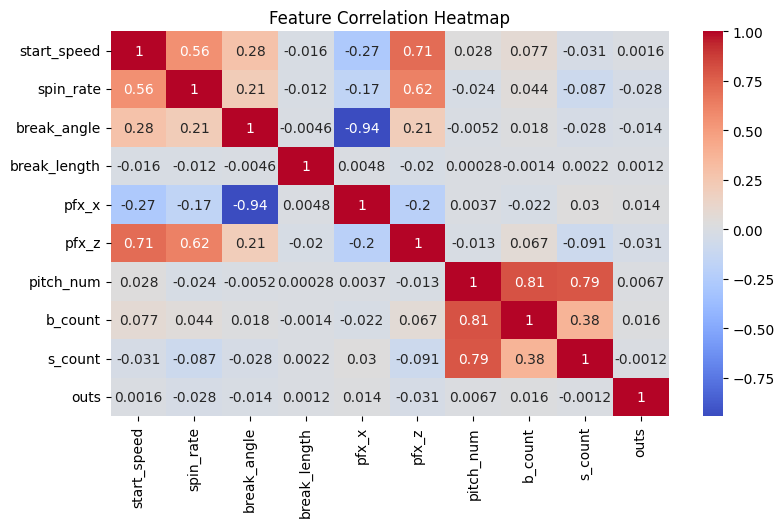

In [20]:
numeric_cols = [
    "start_speed",
    "spin_rate",
    "break_angle",
    "break_length",
    "pfx_x",
    "pfx_z",
    "pitch_num",
    "b_count",
    "s_count",
    "outs"
]

corr = model_df[numeric_cols].corr()

plt.figure(figsize=(9,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Interpretation 

#### The heatmap revealed that spin rate and pitch movement variables showed stronger relationships with pitch velocity than game situation variables such as balls, strikes, and outs. This suggests that physical pitch characteristics may be more important predictors of velocity.

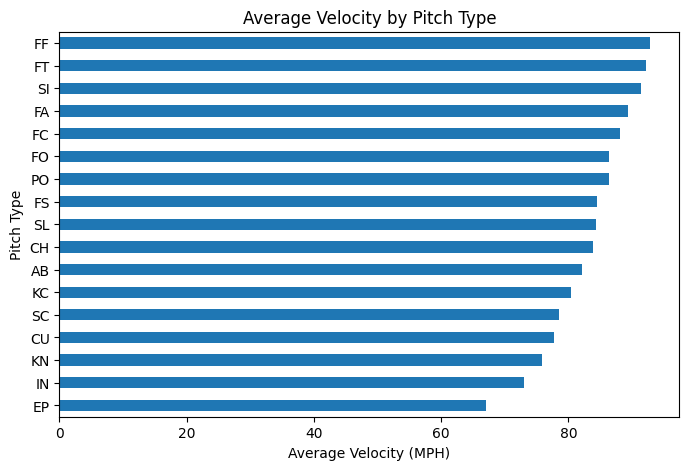

In [21]:
avg_velo = (
    model_df.groupby("pitch_type")["start_speed"]
    .mean()
    .sort_values()
)

avg_velo.plot(
    kind="barh",
    figsize=(8,5)
)

plt.xlabel("Average Velocity (MPH)")
plt.ylabel("Pitch Type")
plt.title("Average Velocity by Pitch Type")

plt.show()

### Interpretation

#### The average velocity bar chart shows clear differences in velocity by pitch type. Fastball-related pitches such as FF, FT, and SI have the highest average velocities, while off-speed or specialty pitches such as EP, KN, and UN have much lower average velocities. This confirms that pitch type is an important feature for predicting pitch velocity.

# Feature Encoding

### I need to make a couple of the features that are not binary. Into binary, this would include pitch type. Based on the charts done earlier in cleaning we can see that the runners on are already in binary. 

In [22]:
X = pd.get_dummies(
    model_df[features],
    drop_first=True
)

X.head()

,b_count,s_count,outs,pitch_num,on_1b,on_2b,on_3b,spin_rate,break_angle,break_length,...,pitch_type_FO,pitch_type_FS,pitch_type_FT,pitch_type_IN,pitch_type_KC,pitch_type_KN,pitch_type_PO,pitch_type_SC,pitch_type_SI,pitch_type_SL
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2305.052,-25.0,3.2,...,False,False,False,False,False,False,False,False,False,False
1,0.0,1.0,0.0,2.0,0.0,0.0,0.0,2689.935,-40.7,3.4,...,False,False,False,False,False,False,False,False,False,False
2,0.0,2.0,0.0,3.0,0.0,0.0,0.0,2647.972,-43.7,3.7,...,False,False,False,False,False,False,False,False,False,False
3,0.0,2.0,0.0,4.0,0.0,0.0,0.0,1289.590,-1.3,5.0,...,False,False,False,False,False,False,False,False,False,False
4,1.0,2.0,0.0,5.0,0.0,0.0,0.0,1374.569,18.4,12.0,...,False,False,False,False,False,False,False,False,False,False


In [23]:
print(X.head())

   b_count  s_count  outs  pitch_num  on_1b  on_2b  on_3b  spin_rate  \
0      0.0      0.0   0.0        1.0    0.0    0.0    0.0   2305.052   
1      0.0      1.0   0.0        2.0    0.0    0.0    0.0   2689.935   
2      0.0      2.0   0.0        3.0    0.0    0.0    0.0   2647.972   
3      0.0      2.0   0.0        4.0    0.0    0.0    0.0   1289.590   
4      1.0      2.0   0.0        5.0    0.0    0.0    0.0   1374.569   

   break_angle  break_length  ...  pitch_type_FO  pitch_type_FS  \
0        -25.0           3.2  ...          False          False   
1        -40.7           3.4  ...          False          False   
2        -43.7           3.7  ...          False          False   
3         -1.3           5.0  ...          False          False   
4         18.4          12.0  ...          False          False   

   pitch_type_FT  pitch_type_IN  pitch_type_KC  pitch_type_KN  pitch_type_PO  \
0          False          False          False          False          False   
1   

### What the model is going to learn
"If the pitch has:
- high spin rate
- certain movement
- certain pitch type
- certain count
then the velocity is likely around X MPH"

# Training and Testing

In [24]:
# We need to set our x and y (separate target and features)

X = model_df.drop(columns=["start_speed"])
y = model_df["start_speed"]

X = pd.get_dummies(X, drop_first=True)

print(X.head())

   b_count  s_count  outs  pitch_num  on_1b  on_2b  on_3b  spin_rate  \
0      0.0      0.0   0.0        1.0    0.0    0.0    0.0   2305.052   
1      0.0      1.0   0.0        2.0    0.0    0.0    0.0   2689.935   
2      0.0      2.0   0.0        3.0    0.0    0.0    0.0   2647.972   
3      0.0      2.0   0.0        4.0    0.0    0.0    0.0   1289.590   
4      1.0      2.0   0.0        5.0    0.0    0.0    0.0   1374.569   

   break_angle  break_length  ...  pitch_type_FO  pitch_type_FS  \
0        -25.0           3.2  ...          False          False   
1        -40.7           3.4  ...          False          False   
2        -43.7           3.7  ...          False          False   
3         -1.3           5.0  ...          False          False   
4         18.4          12.0  ...          False          False   

   pitch_type_FT  pitch_type_IN  pitch_type_KC  pitch_type_KN  pitch_type_PO  \
0          False          False          False          False          False   
1   

In [25]:
#Time for training

# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("split into training and testing")

split into training and testing


In [26]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2009091, 28)
X_test shape: (502273, 28)
y_train shape: (2009091,)
y_test shape: (502273,)


### Train/Test Split

The dataset was divided into training and testing sets using an 80/20 split. The training set was used to train the regression models, while the testing set was reserved for evaluating model performance on unseen data.

In [27]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print("complete")

complete


In [28]:
print("Linear Regression Results")

print("MAE:",
      mean_absolute_error(y_test, lr_preds))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_preds)))

print("R2:",
      r2_score(y_test, lr_preds))

Linear Regression Results
MAE: 2.3285633367040317
RMSE: 3.0045900411715354
R2: 0.7502590587548625


### Linear Regression Interpretation

The Linear Regression model produced strong overall performance when predicting MLB pitch velocity. The model achieved a Mean Absolute Error (MAE) of approximately 2.33 MPH, meaning predictions were typically within about 2–3 MPH of the actual pitch velocity.

The Root Mean Squared Error (RMSE) was approximately 3.00 MPH, indicating that larger prediction errors were relatively limited throughout the dataset.

The model achieved an R² value of 0.75, meaning approximately 75% of the variation in pitch velocity was explained by the selected features. This suggests that variables such as pitch type, spin rate, pitch movement, and game situation information were effective predictors of pitch velocity.

Overall, the Linear Regression model demonstrated strong predictive capability and provided a solid baseline model for evaluating more advanced regression techniques.

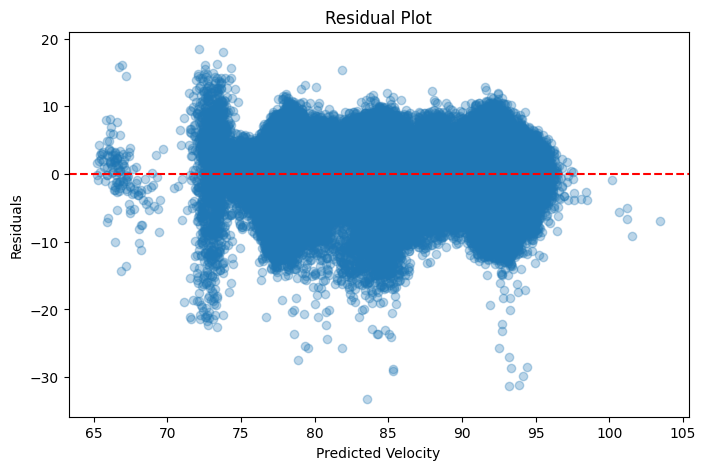

In [29]:
residuals = y_test - lr_preds

plt.figure(figsize=(8,5))

plt.scatter(
    lr_preds,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Velocity")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Interpretation

The residual plot shows how far off the model predictions were from the actual pitch velocities. Most of the residuals are centered around zero, which means the model was generally making solid predictions across the dataset.

There is still some spread and a few outliers, especially in certain velocity ranges, showing that some pitches were harder for the model to predict accurately. This could be caused by factors not included in the dataset, such as pitcher-specific mechanics or game situations.

Overall, the residual plot suggests the Linear Regression model performed well and was able to capture most of the patterns related to pitch velocity.

## Polynomial Regression

this might take a minute.

In [30]:
poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(X_train)

X_poly_test = poly.transform(X_test)


In [31]:
poly_model = LinearRegression()

poly_model.fit(X_poly_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
poly_preds = poly_model.predict(X_poly_test)

In [33]:
print("Polynomial Regression Results")

print("MAE:",
      mean_absolute_error(y_test, poly_preds))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, poly_preds)))

print("R2:",
      r2_score(y_test, poly_preds))

Polynomial Regression Results
MAE: 0.6920892797914054
RMSE: 0.8926892717439568
R2: 0.9779545012641204



### Interpretation

The Polynomial Regression model performed much better than the original Linear Regression model. The MAE dropped to about 0.69 MPH and the RMSE was under 1 MPH, showing that the model was able to predict pitch velocity very accurately.

The model also achieved an R² score of about 0.98, meaning it explained nearly 98% of the variation in pitch velocity throughout the dataset.

These results show that pitch velocity is not completely linear. Factors such as pitch movement, spin rate, and pitch type interact with each other in more complex ways, and the Polynomial Regression model was able to capture those relationships much better than the standard Linear Regression model.

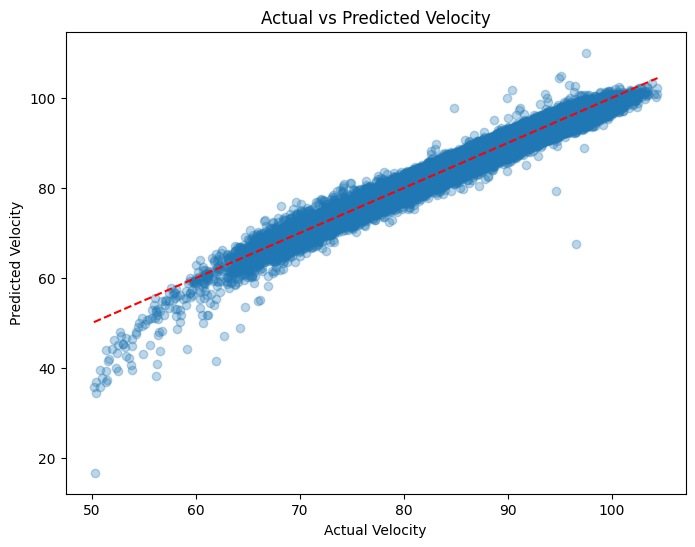

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    poly_preds,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Velocity")
plt.ylabel("Predicted Velocity")

plt.title("Actual vs Predicted Velocity")

plt.show()

### Interpretation

The Actual vs Predicted Velocity graph shows that the Polynomial Regression model did a very strong job predicting pitch velocity. Most of the points stay close to the trend line, which means the predicted velocities were usually very close to the actual pitch velocities.

There are still a few outliers, especially in some of the lower velocity pitches, where the model was not as accurate. However, the overall pattern shows a strong relationship between the actual and predicted values.

Overall, this graph supports the high R² score from the model and shows that the Polynomial Regression model was able to capture the relationships in the dataset very effectively.

# Ridge Regression

In [37]:
import warnings
from scipy.linalg import LinAlgWarning

warnings.filterwarnings("ignore", category=LinAlgWarning)

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {
    "alpha": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_poly_train, y_train)

print("Best Alpha:", grid.best_params_)


Best Alpha: {'alpha': 0.01}


In [39]:
best_ridge = grid.best_estimator_

ridge_grid_preds = best_ridge.predict(X_poly_test)

print("Tuned Ridge Regression Results")
print("MAE:", mean_absolute_error(y_test, ridge_grid_preds))
print("RMSE:", mean_squared_error(y_test, ridge_grid_preds) ** 0.5)
print("R2:", r2_score(y_test, ridge_grid_preds))

Tuned Ridge Regression Results
MAE: 0.6838613568793651
RMSE: 0.8762666195544341
R2: 0.9787581746682148


### Hyperparameter Tuning

For Ridge Regression, I used GridSearchCV to test different alpha values. Alpha controls how much regularization is applied to the model. A higher alpha adds more penalty to large coefficients, while a lower alpha allows the model to behave more like standard Linear Regression.

The best alpha was selected based on the highest cross-validation R² score.

### Interpretation

The Ridge Regression model produced results that were almost identical to the Polynomial Regression model, with only slight improvements in the evaluation metrics. This suggests that the Polynomial model was already performing very well.

Ridge Regression helped make the model slightly more stable by reducing the risk of overfitting while still maintaining very strong prediction accuracy.

# Comparison
 The Polynomial and Ridge Regression models both outperformed the standard Linear Regression model by a large margin. Both advanced models produced much lower prediction error and significantly higher R² values.

 While the Ridge Regression model only slightly improved the results compared to Polynomial Regression, it helped reduce the risk of overfitting and created a more stable model overall.

In [43]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression"
    ],

    "MAE": [
        mean_absolute_error(y_test, lr_preds),
        mean_absolute_error(y_test, poly_preds),
        mean_absolute_error(y_test, ridge_grid_preds)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        np.sqrt(mean_squared_error(y_test, poly_preds)),
        np.sqrt(mean_squared_error(y_test, ridge_grid_preds))
    ],

    "R2": [
        r2_score(y_test, lr_preds),
        r2_score(y_test, poly_preds),
        r2_score(y_test, ridge_grid_preds)
    ]
})

comparison_df

,Model,MAE,RMSE,R2
0,Linear Regression,2.328563,3.004590,0.750259
1,Polynomial Regression,0.692089,0.892689,0.977955
2,Ridge Regression,0.683861,0.876267,0.978758


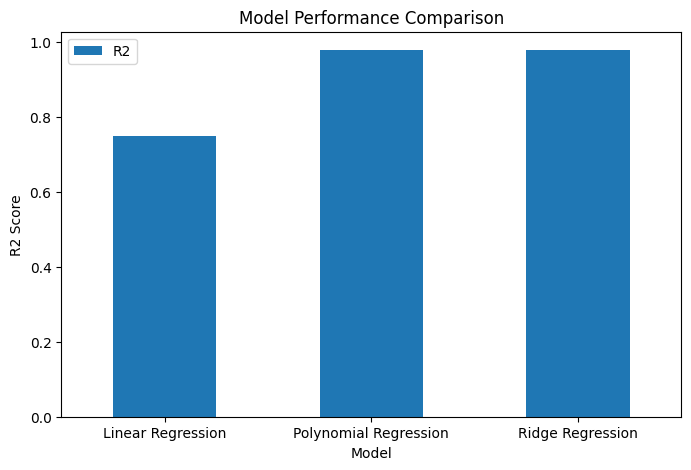

In [44]:
comparison_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("R2 Score")
plt.title("Model Performance Comparison")

plt.xticks(rotation=0)

plt.show()

## The polynomial and ridge are extremly close. 

## Final Conclusion

This project used regression models to predict MLB pitch velocity using pitch type, spin rate, movement data, and game situation variables.

Linear Regression gave a solid baseline, but Polynomial Regression and Ridge Regression performed much better because they captured more complex relationships in the data. Ridge Regression was selected as the final model because it produced the strongest results while also adding regularization to help control overfitting.

One limitation is that the dataset did not include pitcher-specific information, which would likely improve the model even more. Overall, the project showed that machine learning can predict pitch velocity very accurately using pitch-level baseball data.